# 0.37 — The three basket methods, through deck 8's backtest

Same experiment as **0.35**, with one thing changed: instead of one basket per theme, each theme is
run through the **three ranking methods** of 0.36. The harness, the metrics and the presentation are
0.35's, unmodified.

**Strategy**: equal weights, buy at the theme's information date, hold 3 months, rebalance, repeat.
Periods are contiguous — each exit day *is* the next entry day.

**Formulas** — per period $i$, over held names $H_i$:

$$r_i = \tfrac{1}{|H_i|}\textstyle\sum_{j \in H_i}\bigl(P_j(t_{i+1})/P_j(t_i) - 1\bigr)
\qquad R=\textstyle\sum_i r_i \qquad \text{ratio}=R/\sigma \qquad
\text{Sharpe}_{ann}=\bar r/\sigma\cdot\sqrt{12/m}$$

$P$ = Yahoo auto-adjusted closes. $\sigma$ = std of the $r_i$ (ddof=1). The ratio $R/\sigma$ is
comparable only *within* a window; across themes use **Sharpe**. Each section benchmarks SPY on the
same window.

**The three methods** (0.36), all from the same theme words and the same filings:

1. **count** — breadth of theme words hit, density as tie-break *(the deck-8 rule)*
2. **density** — mentions per 1k words, floor of 10 hits
3. **weighted** — rarity-weighted density, ≥2 non-generic words

**Entry dates**: quantum **2022-09-30**, genAI **2023-01-17** (the promotion week). 0.35's code carries
`start="2023-05-18"` for genAI, but its own heading and deck 8 both say January, and only January
reproduces the deck's twelve printed quarterly returns.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CODE = Path.cwd().parent
sys.path.insert(0, str(CODE))
import theme_backtest as bt
import theme_basket as tb

PROC = CODE / "data" / "processed"
pd.set_option("display.width", 220)

END, MONTHS = "2025-12-31", 3
GRAY = "#7a7a75"
COLOR = {"1 count": "#b0752a", "2 density": "#2a78d6", "3 weighted": "#1baf7a",
         "deck-8 list": "#eb6834"}
THEMES = {"quantum": ("quantum_2022-09-30", "2022-09-30"),
          "genai":   ("genai_2023-01-17",   "2023-01-17")}
TOP = 10

load = lambda n: pd.read_parquet(PROC / f"theme_basket_{n}.parquet")
meta = lambda n: json.loads((PROC / f"theme_basket_{n}_manifest.json").read_text())

def baskets(theme):
    '''The same theme words ranked three ways -> three top-10 ticker lists.'''
    name = THEMES[theme][0]
    b = load(name)
    out = {"1 count":    b.sort_values(["n_terms_hit", "per_1k_words"], ascending=False),
           "2 density":  b,
           "3 weighted": tb.rank_specificity(b, meta(name))}
    return {k: v.ticker.head(TOP).tolist() for k, v in out.items()}

BASKETS = {t: baskets(t) for t in THEMES}
# deck 8's own genAI basket, kept for continuity: it holds EA, which no longer resolves to a
# CIK and so cannot be re-selected by any method today
BASKETS["genai"]["deck-8 list"] = ["NVDA", "TRIP", "GOOG", "EA", "MYPS", "APPS",
                                   "EXPE", "EBAY", "CRNC", "FFAI"]
# deck 8's quantum basket is the four rule-selected pure-plays, NOT a top-10 — kept at its
# own size, so this row is a like-for-like replication of the deck rather than a method
BASKETS["quantum"]["deck-8 list"] = ["IONQ", "QUBT", "RGTI", "QBTS"]

px = bt.load_prices(sorted({t for m in BASKETS.values() for v in m.values() for t in v} | {"SPY"}),
                    verbose=False)
print(f"prices ready: {px.shape[1]} tickers")
for theme, m in BASKETS.items():
    print(f"\n{theme} (entry {THEMES[theme][1]}):")
    for lab, tk in m.items():
        print(f"  {lab:12} {' '.join(tk)}")

prices ready: 32 tickers

quantum (entry 2022-09-30):
  1 count      IONQ QUBT RGTI QBTS LODE IBM RBBN BZAI MRSH AMPG
  2 density    QUBT IONQ QBTS RGTI QSI QMCO GEOS BZAI LODE AMPG
  3 weighted   QUBT IONQ QBTS RGTI BZAI LODE MRSH AMPG HON IBM
  deck-8 list  IONQ QUBT RGTI QBTS

genai (entry 2023-01-17):
  1 count      NVDA TRIP GOOG MYPS APPS EXPE EBAY CRNC FFAI BKNG
  2 density    GOOG NVDA TJX MYPS BKNG OKLO AMD SIRI TRIP CSPI
  3 weighted   NVDA GOOG OKLO TRIP EXPE ABNB EBAY CRNC FFAI
  deck-8 list  NVDA TRIP GOOG EA MYPS APPS EXPE EBAY CRNC FFAI


`report` and `plot_curves` below are 0.35's, widened to take several baskets at once.

In [2]:
def report(theme, end=END, months=MONTHS):
    '''0.35's table: summed period returns, std, ratio, annualized Sharpe — vs SPY, same window.'''
    start = THEMES[theme][1]
    print(f"window {start} -> {end} · rebalance every {months}m · equal weight · top {TOP}")
    print(f"{'':13}{'n':>3} {'sum rets':>10} {'std':>8} {'ret/risk':>9} {'Sharpe ann':>11}")
    out = {}
    for label, tk in list(BASKETS[theme].items()) + [("SPY", ["SPY"])]:
        r, tot, ratio = bt.rebalance_backtest(px, tk, start, end, months=months)
        sh = float(r.mean() / r.std(ddof=1) * (12 / months) ** 0.5)
        print(f"{label:13}{len(r):>3} {tot:>10.1%} {r.std(ddof=1):>8.1%} {ratio:>9.2f} {sh:>11.2f}")
        out[label] = r
    return pd.DataFrame(out)

def plot_curves(theme, end=END, months=MONTHS):
    start = THEMES[theme][1]
    fig, ax = plt.subplots(figsize=(9, 4.6))
    series = [(lab, tk, COLOR.get(lab, GRAY), "-", 2) for lab, tk in BASKETS[theme].items()]
    series.append(("SPY", ["SPY"], GRAY, "--", 1.6))
    for label, tk, col, ls, lw in series:
        c = bt.rebalance_curve(px, tk, start, end, months=months)
        ax.plot(c.index, c, color=col, ls=ls, lw=lw, label=label)
        ax.annotate(f" {label} {c.iloc[-1] - 1:+.0%}", (c.index[-1], c.iloc[-1]),
                    color=col, fontsize=8.5, fontweight="bold", va="center")
    ax.set_yscale("log"); ax.set_yticks([0.25, 0.5, 1, 2, 4, 8, 16, 32])
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}x"))
    ax.grid(alpha=0.25, lw=0.5); ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(f"{theme} — equal weight, {months}m rebalance, from its info date {start} (log)",
                 fontsize=11)
    ax.legend(frameon=False, loc="upper left"); ax.margins(x=0.18)
    plt.tight_layout(); plt.show()

def periods(rets):
    '''Deck-8 style: the quarterly returns behind each row.'''
    for lab in rets.columns:
        print(f"{lab:13} " + ", ".join(f"{v:+.0f}" for v in (rets[lab] * 100)))

## 1 · Quantum — from its info date 2022-09-30

In [3]:
rq = report("quantum")

window 2022-09-30 -> 2025-12-31 · rebalance every 3m · equal weight · top 10
               n   sum rets      std  ret/risk  Sharpe ann
1 count       14     763.1%   181.1%      4.21        0.60
2 density     14     923.0%   233.6%      3.95        0.56
3 weighted    14     762.6%   180.7%      4.22        0.60
deck-8 list   14    1669.6%   405.9%      4.11        0.59
SPY           14      72.5%     5.2%     13.99        2.00


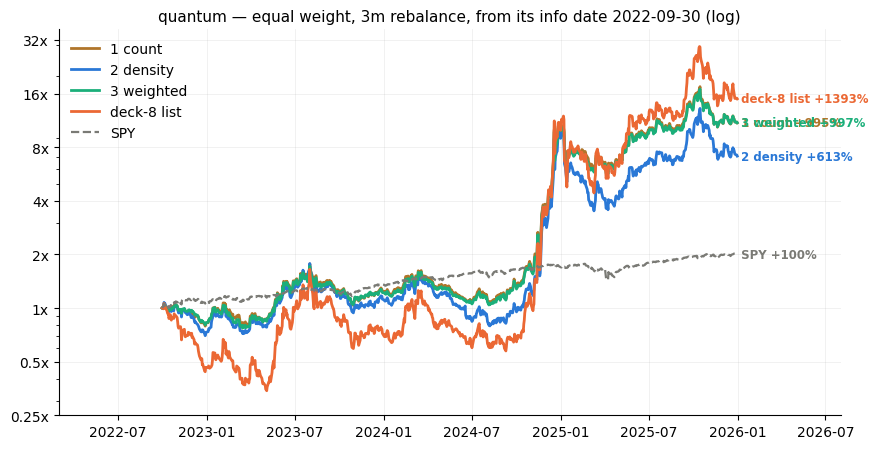

In [4]:
plot_curves("quantum")

In [5]:
print("3M returns (%)"); periods(rq)

3M returns (%)
1 count       -17, -0, +68, -10, -0, +19, -27, +25, +675, -38, +53, +33, -16, -1
2 density     -27, +4, +69, -9, -6, +23, -38, +18, +868, -58, +65, +35, -20, -1
3 weighted    -17, -4, +71, -10, -1, +19, -27, +25, +673, -38, +54, +33, -14, -1
deck-8 list   -54, -13, +140, -11, -19, +48, -42, +13, +1516, -45, +94, +65, -22, -1
SPY           +8, +6, +10, -3, +11, +11, +5, +6, +3, -5, +11, +8, +3, -1


**The deck-8 row is an exact replication.** Its four rule-selected pure-plays reproduce deck 8's
printed quarterly series (`-54, -13, +140, ..., +1516, ...`) and its Sharpe of **0.59** to the decimal.
Note it is a *four-name* basket, not a top-10 — the three methods below are ten names each, so they are
comparable to each other but not directly to that row.

The three methods land on top of each other: **0.60 / 0.56 / 0.60**. They do not hold the same names —
methods 1 and 3 differ in half the basket — but IONQ, QUBT, RGTI and QBTS are in all three, and under
equal weight those four carry the entire result. Positions 5–10 cannot move it.

Every basket also loses to SPY on Sharpe despite returning several hundred percent: σ is ~180-230% a
quarter. The deck's own reading applies unchanged — one quarter carries everything.

## 2 · genAI — from its info date 2023-01-17

In [6]:
rg = report("genai")

window 2023-01-17 -> 2025-12-31 · rebalance every 3m · equal weight · top 10
               n   sum rets      std  ret/risk  Sharpe ann
1 count       12     104.8%    26.4%      3.96        0.66
2 density     12     110.0%    14.6%      7.55        1.26
3 weighted    12     174.4%    29.6%      5.90        0.98
deck-8 list   12     106.0%    28.7%      3.70        0.62
SPY           12      62.4%     7.6%      8.16        1.36


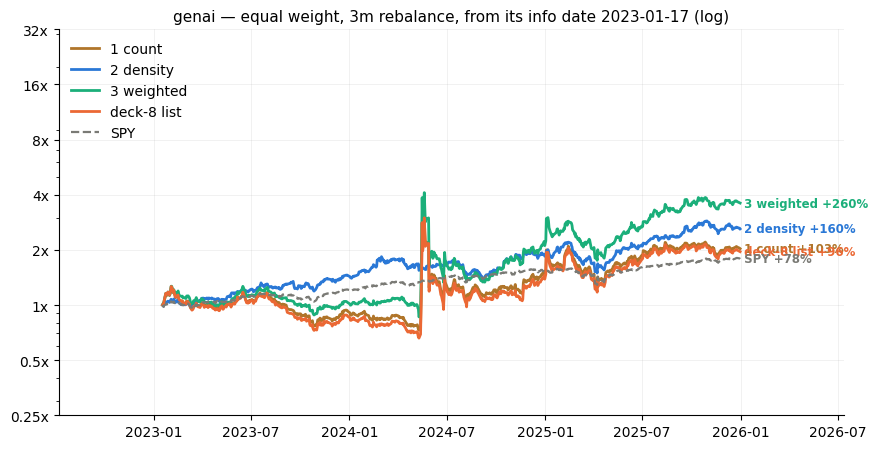

In [7]:
plot_curves("genai")

In [8]:
print("3M returns (%)"); periods(rg)

3M returns (%)
1 count       -0, +15, -24, -0, -9, +66, -5, +31, -15, +45, +4, -3
2 density     +9, +16, +3, +13, +12, +4, +1, +11, -16, +43, +20, -5
3 weighted    +3, +18, -19, +2, +0, +66, +1, +42, -23, +67, +20, -3
deck-8 list   -2, +16, -27, -2, -10, +72, -6, +33, -16, +48, +5, -4
SPY           +4, +9, -3, +9, +6, +12, +5, +3, -12, +20, +6, +3


Here the methods separate — density **1.26**, weighted **0.98**, count **0.66** — and the deck-8 list
(**0.62**) sits with count, as it should: it is the same rule, one name apart. That gap is not evidence
about ranking, though. Every genAI basket is noise underneath: method 2's third name is TJX (its CEO is
Ernie Herrman), method 3's is Oklo (a nuclear company Sam Altman chaired). What actually differs between
these baskets is how much of the book sits in NVDA and GOOG.

**Replication check:** deck 8 reports genAI **0.64**; its list here gives **0.62**, with the quarterly
series matching sign-for-sign. The residual is Yahoo restating adjusted closes since July — deck 8's
exact figures are no longer reproducible, only their shape. Quantum replicates exactly (§1).

## 3 · Reading the two together

The windows differ, so compare across themes with **Sharpe** only.

In [9]:
rows = {}
for theme in THEMES:
    start = THEMES[theme][1]
    for lab, tk in BASKETS[theme].items():
        r, _, _ = bt.rebalance_backtest(px, tk, start, END, months=MONTHS)
        sd = r.std(ddof=1)
        full = float(r.mean() / sd * (12 / MONTHS) ** 0.5)
        d = r.drop(r.idxmax())
        rows[(theme, lab)] = {"Sharpe": full,
                              "drop best quarter": float(d.mean() / d.std(ddof=1) * (12 / MONTHS) ** 0.5),
                              "1m": None, "3m": full, "6m": None}
    for m in (1, 6):
        for lab, tk in BASKETS[theme].items():
            r, _, _ = bt.rebalance_backtest(px, tk, start, END, months=m)
            rows[(theme, lab)][f"{m}m"] = float(r.mean() / r.std(ddof=1) * (12 / m) ** 0.5)
pd.DataFrame(rows).T[["Sharpe", "drop best quarter", "1m", "3m", "6m"]].round(2)

Sharpe  drop best quarter    1m    3m    6m
quantum 1 count        0.60               0.43  0.95  0.60  0.74
        2 density      0.56               0.23  0.84  0.56  0.68
        3 weighted     0.60               0.43  0.94  0.60  0.74
        deck-8 list    0.59               0.40  0.97  0.59  0.68
genai   1 count        0.66               0.35  0.59  0.66  0.84
        2 density      1.26               1.18  1.32  1.26  3.75
        3 weighted     0.98               0.76  0.75  0.98  1.27
        deck-8 list    0.62               0.29  0.56  0.62  0.72

**Fragility** (deck 8's own check): dropping one quarter costs 0.17–0.33 on quantum. The spread
*between methods* there is 0.04. The differences we are trying to measure are an order of magnitude
smaller than the noise in each measurement.

**Rebalance frequency** was never justified in 0.35 — `MONTHS = 3` is a default. The ordering of the
methods is roughly stable across 1m/3m/6m on quantum, less so on genAI. Ignore genAI's 6m figure: it
comes from about six periods, and a Sharpe from six points is not a measurement.

## 4 · Beyond the deck: weighting by the score

Equal weight discards the ranking — if position 1 is not held more heavily than position 10, a better
*ordering* cannot show up. `theme_backtest.rebalance_backtest_weighted` mirrors the equal-weight
function (and reproduces it exactly when weights are equal); each method sizes positions by its own
score.

In [10]:
import numpy as np

SCORE = {"1 count": "total", "2 density": "per_1k_words", "3 weighted": "weighted"}

def ranked(theme, lab):
    name = THEMES[theme][0]
    b = load(name)
    return {"1 count":    b.sort_values(["n_terms_hit", "per_1k_words"], ascending=False),
            "2 density":  b,
            "3 weighted": tb.rank_specificity(b, meta(name))}[lab].head(TOP)

def weights(theme, lab, scheme):
    d = ranked(theme, lab); s = d[SCORE[lab]].astype(float).clip(lower=0)
    w = {"equal":        pd.Series(1.0, index=d.ticker),
         "proportional": pd.Series(s.values, index=d.ticker),
         "sqrt":         pd.Series(np.sqrt(s.values), index=d.ticker),
         "rank":         pd.Series(1 / np.arange(1, len(d) + 1), index=d.ticker)}[scheme]
    return w / w.sum()

rows = {}
for theme in THEMES:
    start = THEMES[theme][1]
    for lab in SCORE:
        for sch in ("equal", "proportional", "sqrt", "rank"):
            w = weights(theme, lab, sch)
            r, tot, _ = bt.rebalance_backtest_weighted(px, list(w.index), w.to_dict(), start, END,
                                                       months=MONTHS)
            sd = r.std(ddof=1)
            rows[(theme, lab, sch)] = {"sum R": tot, "sigma": float(sd),
                                       "Sharpe ann": float(r.mean() / sd * (12 / MONTHS) ** 0.5),
                                       "top-2 weight": float(w.nlargest(2).sum())}
print(pd.DataFrame(rows).T.to_string(
    formatters={"sum R": "{:+.0%}".format, "sigma": "{:.0%}".format,
                "Sharpe ann": "{:.2f}".format, "top-2 weight": "{:.0%}".format}))

                                 sum R sigma Sharpe ann top-2 weight
quantum 1 count    equal         +763%  181%       0.60          20%
                   proportional +1425%  347%       0.59          73%
                   sqrt         +1304%  317%       0.59          51%
                   rank         +1066%  252%       0.60          51%
        2 density  equal         +923%  234%       0.56          20%
                   proportional +1508%  381%       0.57          50%
                   sqrt         +1248%  315%       0.57          36%
                   rank         +1474%  379%       0.56          51%
        3 weighted equal         +763%  181%       0.60          20%
                   proportional +1617%  402%       0.57          58%
                   sqrt         +1288%  315%       0.58          42%
                   rank         +1388%  350%       0.57          51%
genai   1 count    equal         +105%   26%       0.66          20%
                   proportional  +

**quantum**: returns double, σ doubles with them, Sharpe unmoved (0.56–0.60). Concentrating into names
that already dominate is leverage, not selection.

**genAI**: every method jumps past SPY — weighted reaches **1.83**. But its weights are NVDA **51%**,
GOOG **33%**: 84% of the book in two names. That is a concentrated NVIDIA position, and NVIDIA earns
that weight by saying the word `nvidia` 600 times in its own filings. Real in the numbers, worthless
as evidence about ranking.

Score weighting also carries a **size tilt**: a small pure-play's filing is entirely about its theme,
so quantum's largest weight (33%) goes to QUBT, a microcap. Deck 8 already flagged that these baskets
assume no transaction costs or market impact "(microcaps!)"; this puts the most capital exactly where
that assumption is weakest. `sqrt` and `rank` give most of the effect at roughly half the concentration.

---
## Conclusion

The ranking methods fix defects that are visible in the basket — Quantum-Si, TJX, Ultragenyx — and the
backtest cannot see the difference. On quantum the methods are separated by 0.04 while each is fragile
to ±0.25. On genAI they separate, but every basket there is noise and the ranking is standing in for
"how much NVDA".

This is a power problem, not a metric problem: one theme per curve, 12–14 periods. Deck 8's slide 9 —
run the whole chain over many themes and dates, including the duds — is what would make a difference
of this size measurable.